In [1]:
%pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
sys.path.append('ipynb/location/packages')

# Linear program

In [3]:
from ortools.linear_solver import pywraplp


def LinearProgrammingExample():
    """Linear programming sample."""
    solver = pywraplp.Solver.CreateSolver("GLOP")
    if not solver:
        return

    x = solver.NumVar(0, solver.infinity(), "x")
    y = solver.NumVar(0, solver.infinity(), "y")

    solver.Add(x + 2 * y <= 14.0)
    solver.Add(3 * x - y >= 0.0)
    solver.Add(x - y <= 2.0)
    solver.Maximize(3 * x + 4 * y)

    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print(f"Objective value = {solver.Objective().Value():0.1f}")
        print(f"x = {x.solution_value():0.1f}")
        print(f"y = {y.solution_value():0.1f}")
    else:
        print("The problem does not have an optimal solution.")

LinearProgrammingExample()

Objective value = 34.0
x = 6.0
y = 4.0


In [4]:
from ortools.linear_solver import pywraplp


def LinearProgrammingExample():
    """Linear programming sample."""
    solver = pywraplp.Solver.CreateSolver("SAT")
    if not solver:
        return

    infinity = solver.infinity()
    
    x1 = solver.IntVar(0.0, infinity, "x1")
    x2 = solver.IntVar(0.0, infinity, "x2")
    x3 = solver.IntVar(0.0, infinity, "x3")

    solver.Add(3 * x1 + 6 * x2 + 6 * x3 <= 60)
    solver.Add(x1 + x2 <= 1)
    solver.Add(x2 + x3 <= 1)
    solver.Add(x1 + x3 <= 1)
    solver.Maximize(3 * x1 + 6 * x2 + 6 * x3)

    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print(f"Objective value = {solver.Objective().Value():0.1f}")
        print(f"x1 = {x1.solution_value():0.1f}")
        print(f"x2 = {x2.solution_value():0.1f}")
        print(f"x3 = {x3.solution_value():0.1f}")
    else:
        print("The problem does not have an optimal solution.")

LinearProgrammingExample()

Objective value = 6.0
x1 = 0.0
x2 = 1.0
x3 = 0.0


# Integer program

In [5]:
def main():
    solver = pywraplp.Solver.CreateSolver("SAT")
    if not solver:
        return

    infinity = solver.infinity()
    
    x1 = solver.IntVar(0.0, infinity, "x1")
    x2 = solver.IntVar(0.0, infinity, "x2")
    x3 = solver.IntVar(0.0, infinity, "x3")

    solver.Add(3 * x1 + 6 * x2 + 6 * x3 <= 60)
    solver.Add(x1 + x2 <= 1)
    solver.Add(x2 + x3 <= 1)
    solver.Add(x1 + x3 <= 1)
    solver.Maximize(3 * x1 + 6 * x2 + 6 * x3)

    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print("Objective value =", solver.Objective().Value())
        print("x1 =", x1.solution_value())
        print("x2 =", x2.solution_value())
        print("x3 =", x3.solution_value())
    else:
        print("The problem does not have an optimal solution.")

if __name__ == "__main__":
    main()

Objective value = 6.0
x1 = 0.0
x2 = 1.0
x3 = 0.0


$$
\max z = 16 x_1 + 22 x_2 + 12 x_3 + 8 x_4
\\
\begin{cases}
5 x_1 + 7 x_2 + 4 x_3 + 3 x_4 \leq 14 \\
x_j = {0, 1}
\end{cases}
$$

In [6]:
def main():
    solver = pywraplp.Solver.CreateSolver("SAT")
    if not solver:
        return

    infinity = solver.infinity()
    
    x1 = solver.IntVar(0.0, infinity, "x1")
    x2 = solver.IntVar(0.0, infinity, "x2")
    x3 = solver.IntVar(0.0, infinity, "x3")
    x4 = solver.IntVar(0.0, infinity, "x4")

    solver.Add(5 * x1 + 7 * x2 + 4 * x3 + 3 * x4 <= 14)
    solver.Add(x1 <= 1)
    solver.Add(x2 <= 1)
    solver.Add(x3 <= 1)
    solver.Add(x4 <= 1)
    solver.Maximize(16 * x1 + 22 * x2 + 12 * x3 + 8 * x4)

    status = solver.Solve()

    if status == pywraplp.Solver.OPTIMAL:
        print("Objective value =", solver.Objective().Value())
        print("x1 =", x1.solution_value())
        print("x2 =", x2.solution_value())
        print("x3 =", x3.solution_value())
        print("x4 =", x4.solution_value())
    else:
        print("The problem does not have an optimal solution.")

if __name__ == "__main__":
    main()

Objective value = 42.0
x1 = 0.0
x2 = 1.0
x3 = 1.0
x4 = 1.0


In [7]:
from packages.ortool import programing_const

In [8]:
df = programing_const(
        obj_coeffs=[7, 8, 2, 9, 6],
        constraint_co_leq=[
            [5, 7, 9, 2, 1],
            [18, 4, -9, 10, 12],
            [4, 7, 3, 8, 5],
            [5, 13, 16, 3, -7],
        ],
        bounds_leq=[250, 285, 211, 315],
        constraint_co_eq=[
            [1, 2, 3, 4, 5],
        ],
        bounds_eq=[100],
        num_vars=5,
        num_constraints_leq=4,
        num_constraints_eq=1
    )

df.solver(is_maximization=False, is_integer=True)

Number of variables = 5
Solving with CP-SAT solver v9.14.6206
Objective value = 88.0
x[0]  =  0.0
x[1]  =  0.0
x[2]  =  20.0
x[3]  =  0.0
x[4]  =  8.0

Problem solved in 9 milliseconds
Problem solved in 0 iterations
Problem solved in 0 branch-and-bound nodes


## Plant location

$$
\min z = \sum_{i,j} c_{ij} x_{ij} + \sum_{i} f_i y_i , \\
\begin{cases}
&\sum_i x_{ij} = 1, \quad &(j=\overline{1,n}) \\
&0 \leq x_{ij} \leq y_i \leq 1, \quad &(i=\overline{1,m}, \: j=\overline{1,n})\\
&y_i={0,1} \quad &(i=\overline{1,m})
\end{cases}
$$

e.g.

In [9]:
from packages.GraphView import Graph

ModuleNotFoundError: No module named 'networkx'

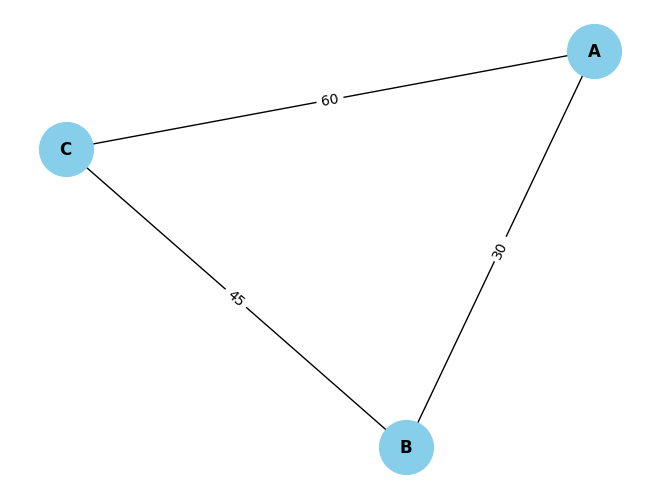

In [ ]:
Global = [
    [0, 30, 60],
    [30, 0, 45],
    [60, 45, 0]
]
df = Graph(Global)
df.show()

$$
\min z = 0x_{11}+30x_{12}+60x_{13}\\
+30x_{21}+0x_{22}+45x_{23}\\
+60x_{31}+45x_{32}+0x_{33}\\
+50y_1+60y_2+40y_3 \\
\\
\begin{cases}
&x_{11}+x_{21}+x_{31}=1\\
&x_{12}+x_{22}+x_{32}=1\\
&x_{13}+x_{23}+x_{33}=1\\
\\
&x_{11}\le y_1,\\
&x_{12}\le y_1,\\
&x_{13}\le y_1,\\
\\
&x_{21}\le y_2,\\
&x_{22}\le y_2,\\
&x_{23}\le y_2,\\
\\
&x_{31}\le y_3,\\
&x_{32}\le y_3,\\
&x_{33}\le y_3,\\
\\
&x_{11},x_{12},x_{13},x_{21},x_{22},x_{23},x_{31},x_{32},x_{33}\ge 0\\
&0 \leq y_1,y_2,y_3 \leq 1
\end{cases}
$$

In [ ]:
df = programing_const(
        obj_coeffs=[0, 30, 60, 30, 0, 45, 60, 45, 0, 50, 60, 40],
        constraint_co_leq=[
            [1, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0],
            [0, 1, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0],
            [0, 0, 1, 0, 0, 0, 0, 0, 0, -1, 0, 0],
            [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, -1, 0],
            [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, -1, 0],
            [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, -1, 0],
            [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, -1],
            [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, -1],
            [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, -1],
            [-1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
        ],
        bounds_leq=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
        constraint_co_eq=[
            [1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0],
            # [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
        ],
        bounds_eq=[1, 1, 1],
        num_vars=12,
        num_constraints_leq=24,
        num_constraints_eq=3
    )

df.solver(is_maximization=False, is_integer=True)

Number of variables = 12
Solving with CP-SAT solver v9.14.6206
Objective value = 120.0
x[0]  =  1.0
x[1]  =  1.0
x[2]  =  0.0
x[3]  =  0.0
x[4]  =  0.0
x[5]  =  0.0
x[6]  =  0.0
x[7]  =  0.0
x[8]  =  1.0
x[9]  =  1.0
x[10]  =  0.0
x[11]  =  1.0

Problem solved in 6 milliseconds
Problem solved in 0 iterations
Problem solved in 0 branch-and-bound nodes


In [ ]:

df.solver(is_maximization=False, is_integer=True)